В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням Decision Trees і зробимо новий submission на змагання на Kaggle.

В цьому ДЗ ми працюємо без pipelines, бо так буде зручніше для візуалізації і інтерпретації моделі дерева прийняття рішень. Так буває і в робочих проєктах: іноді зручніше використати sklearn.Pipelines, іноді зручніше без них. На етапі пошуку рішення (research) зручніше без пайплайнів, а з пайплайнами - коли ви відлагодили процес обробки даних і хочете поекспериментувати з різними моделями і гіперпараметрами.

**Завдання 1.**

У попередньому домашньому завданні, `HW 2.7 Логістична регресія з scikit learn.ipynb`, ми писали обробку даних для змагання. Ваше завдання зараз - за прикладом, наведеним в лекції `Майстер-клас з перенесення коду з jupyter notebook у Python модуль`, перенести попередню обробку сирих даних з вашого розв'язку ДЗ 2.7 у файл `process_bank_churn.py` в функцію `preprocess_data(...)`.

Функція `preprocess_data()` має приймати `raw_df` і вертати `X_train`, `train_targets`, `X_val`, `val_targets`, `input_cols`(перелік назв колонок, які Ви використовуєте в X), `scaler`, `encoder`, які ми потім будемо використовувати для тренування дерева прийняття рішень.


### Кроки попередньої обробки:

1. Обираємо колонки для роботи. В цьому завдання для чистоти експериментів рекомендую прибрати колонку `Surname`, так буде простіше інтрепретувати модель. Ви можете її додати вже за самостійних подальших експериментів.
2. Розбиття сирих даних на тренувальні і валідаційні.
3. Обробка категоріальних даних (one hot encoding).
4. Масштабування числових даних (було частиною попередньої обробки в попередніх завданнях). Для дерев нам не обовʼязково масштабувати ознаки, тож в коді можна зробити цю частину опціональною, додавши в `preprocess_data` параметр `scaler_numeric`, який приймає значення `True` або `False`. Це дозволить використовувати код попередньоъ обробки з різними моделями.


### Інструкції:
1. Перенесіть попередню обробку даних у файл `process_bank_churn.py`.
2. Забезпечте модулярну структуру функцій: кожна функція повинна виконувати лише одну дію, наприклад, масштабувати ознаки.
3. Додайте докстрінги до кожної функції.
4. Використовуйте typing для аргументів та значень, що повертаються функціями.
5. Передбачте обробку нових даних. Додайте спеціальну функцію `preprocess_new_data(...)`, яка приймає на вхід нові дані в вигляді pandas DataFrame та використовує вже навчені скейлер та енкодер (передані теж як аргументи фукнціх) для їх обробки. Ця функція буде корисною для обробки нових даних перед передбаченням або оцінкою моделі, коли оброблятимемо `test.csv`.

Можна і рекомендовано виконувати це завдання з ChatGPT (бажано, новіше, ніж 3.5) як було наведено у відео-прикладі, тільки **ваше додаткове завдання - розібратись з кодом, який вам згенерувала мовна модель :)**.

## В результаті цього завдання

1. Завантажте ваш готовий `process_bank_churn.py` файл на GitHub у свій репозиторій.
2. Додайте посилання на файл в репозиторії тут у ноутбуці.
3. Нижче зробіть імпорт функції `preprocess_data` з вашого модуля `process_bank_churn.py`.



Посилання на файл з методом для обробки даних:
https://github.com/spznk/mlds_tasks/blob/main/md2/topic2.3/process_bank_churn.py

In [182]:
%load_ext autoreload
%autoreload 2

import process_bank_churn as pbc
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import roc_curve, auc

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [183]:
# Read train set from a file
raw_df = pd.read_csv('train.csv')

In [184]:
data = pbc.preprocess_data(raw_df)
print(data.input_cols)

['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


**Завдання 2.**
1. Натренуйте дерево прийняття рішень з зафіксованим `random_state` і з рештою аргументів за замовченням.
2. Виведіть area under ROC для моделі на тренувальних і тестувальних даних. Нам потрібна ця метрика, бо вона основна в змаганні. Модель ок, чи є пере- або недотренування?
3. Виведіть глибину дерева.
4. Побудуйте дерево до глибини 2 включно. Напишіть, які ознаки бачите, що є найвпливовішими тут?
5. Створіть датафрейм `importance_df` з feature importances, де в першому стовпчику `feature` - назва ознаки з нашого Х, а в другому `importance` - значення, наскільки ця ознака є важливою в побудованій моделі. Виведіть топ 10 найвпливовіших ознак разом з їх скором важливості (можна або у вигляді таблиці, або в вигляді barplot).

In [185]:
# Fit Decision Tree with default params
model = DecisionTreeClassifier(random_state=123)
model.fit(data.X_train, data.y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,123
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [186]:
# Function to predict probabilities and show ROC and AUROC
def predict_and_get_auroc(model, set_name, inputs, target, show_roc=False):
    probs = model.predict_proba(inputs)

    fpr, tpr, thresholds = roc_curve(target, probs[:, 1])
    auc_roc = auc(fpr, tpr)

    if show_roc:
        plt.figure()
        plt.plot(fpr, tpr)
        plt.xlabel('fpr')
        plt.ylabel('tpr')
        plt.title(f"{set_name} ROC Curve")
        plt.plot([0, 1], [0, 1], linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.0])
        plt.legend(['ROC Curve', 'y = x'])
        plt.show()

    print(f"{set_name} AUROC:", auc_roc)

    return auc_roc

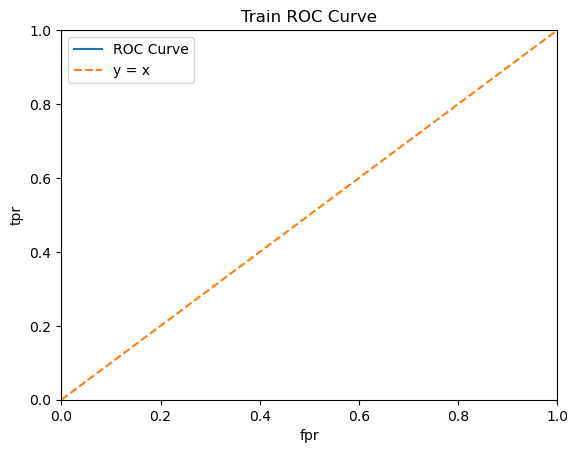

Train AUROC: 1.0


1.0

In [187]:
# Show results for Train
predict_and_get_auroc(model, 'Train', data.X_train, data.y_train, True)

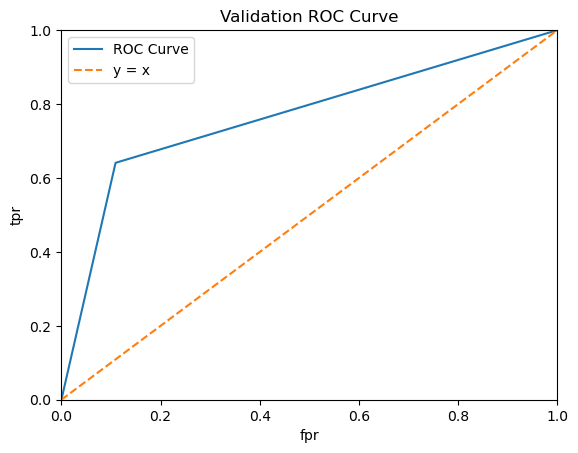

Validation AUROC: 0.7658892928184374


0.7658892928184374

In [188]:
# Show results for Validation
predict_and_get_auroc(model, 'Validation', data.X_val, data.y_val, True)

**Висновок.** Модель показує абсолютно точний результат на Трейні з `AUROC` = 1. На Валідаційному наборі результат суттєво гірший. Це свідчить про явне перетренування.

In [189]:
# Show tree depth
print(model.tree_.max_depth)

26


In [190]:
# Fit Decision Tree with max_depth=2
model_depth_2 = DecisionTreeClassifier(random_state=123, max_depth=2)
model_depth_2.fit(data.X_train, data.y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,123
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


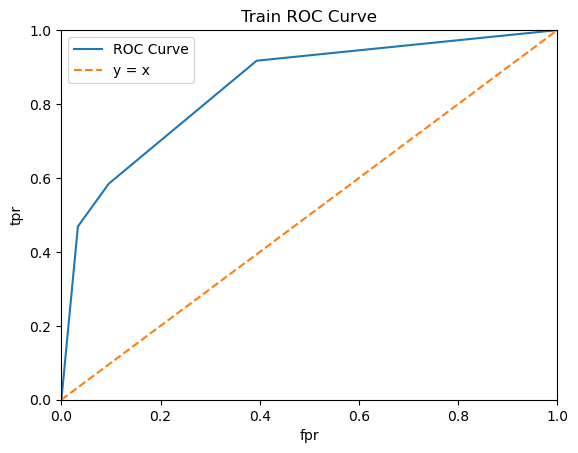

Train AUROC: 0.8457071392570451


0.8457071392570451

In [191]:
# Show results for Train
predict_and_get_auroc(model_depth_2, 'Train', data.X_train, data.y_train, True)

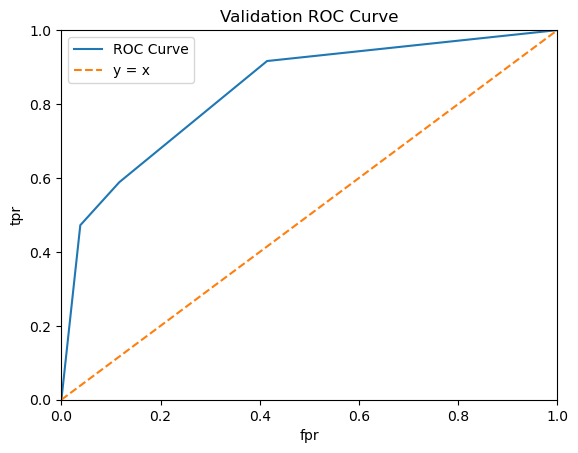

Validation AUROC: 0.8357538239934152


0.8357538239934152

In [192]:
# Show results for Validation
predict_and_get_auroc(model_depth_2, 'Validation', data.X_val, data.y_val, True)

**Висновок.** Для дерева з максимальною глибиною 2 ми бачимо суттєво стабільніший результат для Трейна і Валідейшна. Ознак оверфіту не видно, оскільки значення `AUROC` не сильно відрізняється для них. Дана модель краще передбачає на Валідаційному наборі, ніж попередня.

[Text(0.5, 0.8333333333333334, 'Age <= 0.455\ngini = 0.324\nsamples = 12000\nvalue = [9558, 2442]'),
 Text(0.25, 0.5, 'NumOfProducts <= 0.167\ngini = 0.188\nsamples = 9661\nvalue = [8646, 1015]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'gini = 0.345\nsamples = 3664\nvalue = [2851, 813]'),
 Text(0.375, 0.16666666666666666, 'gini = 0.065\nsamples = 5997\nvalue = [5795, 202]'),
 Text(0.75, 0.5, 'NumOfProducts <= 0.167\ngini = 0.476\nsamples = 2339\nvalue = [912, 1427]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'gini = 0.34\nsamples = 1463\nvalue = [318, 1145]'),
 Text(0.875, 0.16666666666666666, 'gini = 0.437\nsamples = 876\nvalue = [594, 282]')]

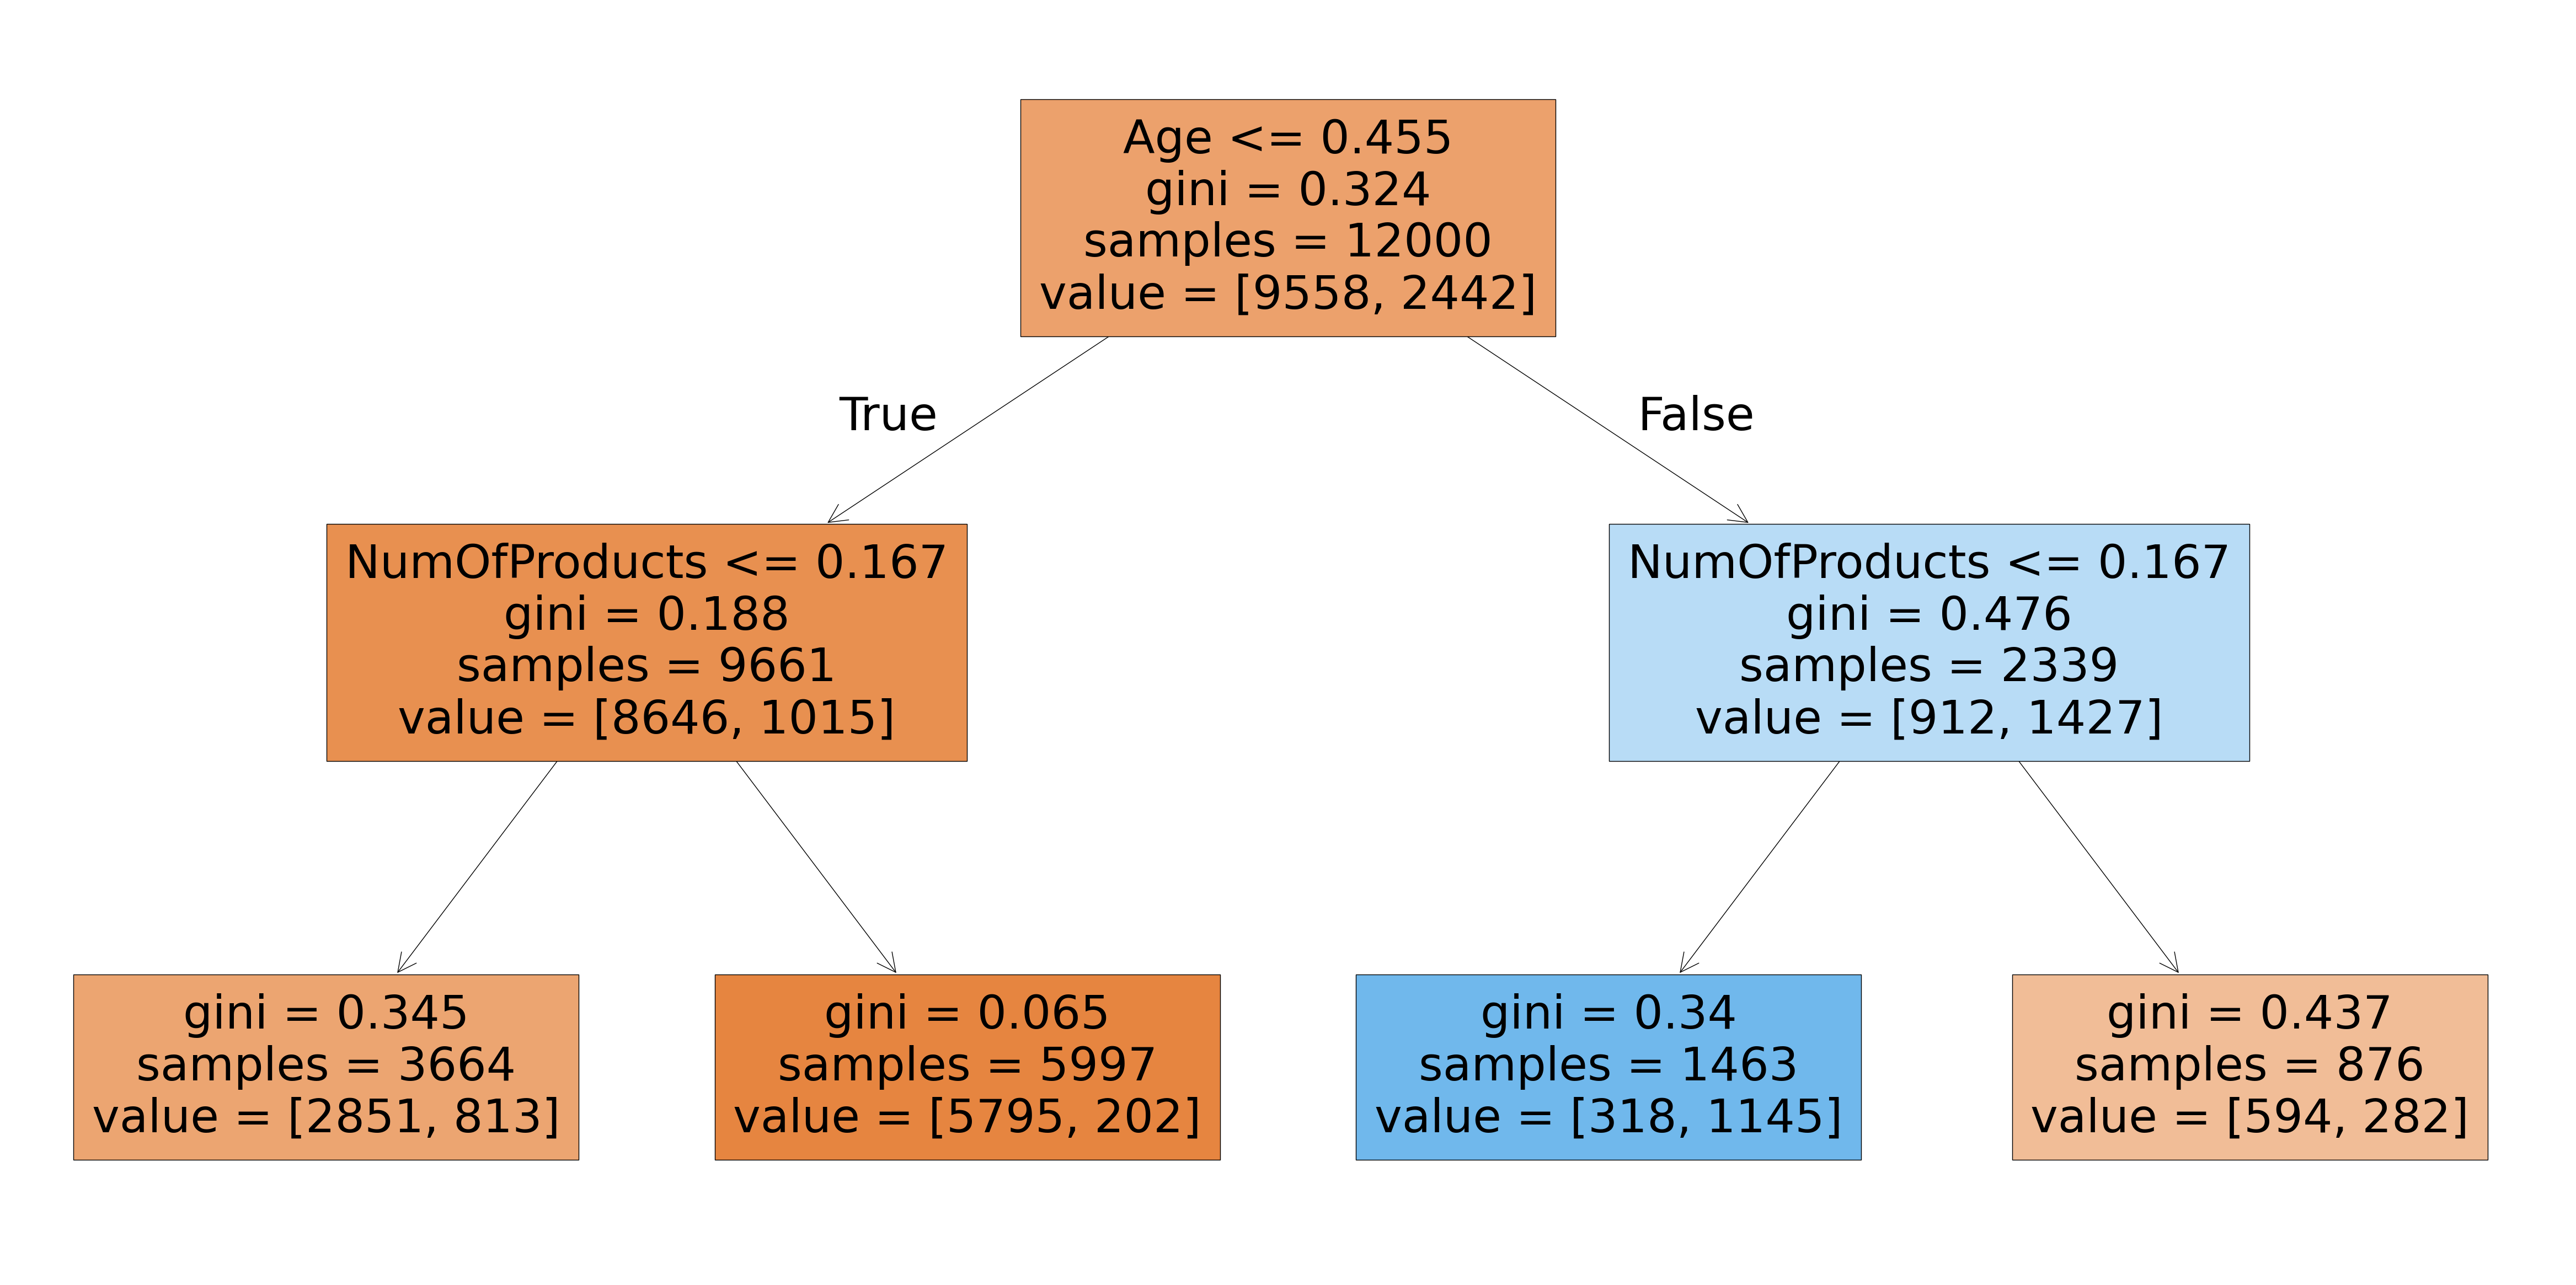

In [193]:
# Draw the tree for model with max_depth=2
plt.figure(figsize=(60, 30))
plot_tree(model_depth_2, feature_names=data.X_train.columns, filled=True)

**Висновок.** Як видно зі схеми, найважливішими ознаками для Дерева з глибиною 2 є `Age` і `NumOfProducts`.

In [194]:
# Show importance of all features for model with default params
importance_df = pd.DataFrame({
    'feature': data.X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
importance_df

,feature,importance
1,Age,0.353152
4,NumOfProducts,0.168046
7,EstimatedSalary,0.129348
0,CreditScore,0.120174
3,Balance,0.085477
2,Tenure,0.052161
6,IsActiveMember,0.036366
9,Geography_Germany,0.016876
11,Gender_Male,0.016511
5,HasCrCard,0.010367


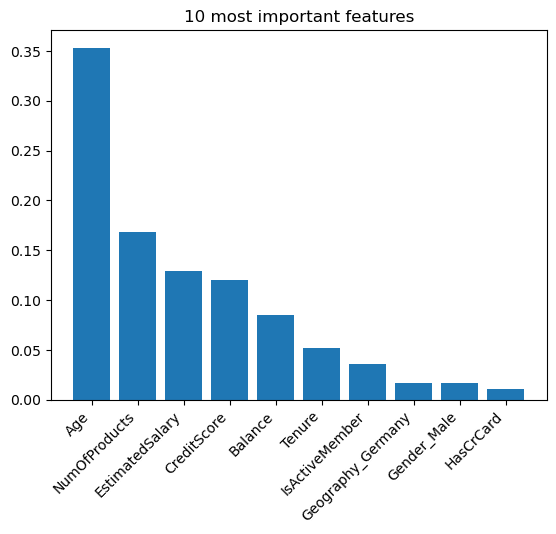

In [195]:
# Show 10 most important features on a bar plot
plt.bar(importance_df.feature[:10], importance_df.importance[:10])
plt.title("10 most important features")
plt.xticks(rotation=45, ha='right')
plt.show()

**Завдання 3**. Спробуйте знайти такі параметри моделі `DecisionTree` аби модель генералізувала ліпше (був вищий показник AUROC на валідаційній вибірці). Проекспериментуйте з різними значеннями параметрів `max_leaf_nodes`, `max_depth` та лишіть ті, які дають найкращий результат, разом з відповідними AUROC на тренувальній і валідаційній вибірках.

В цьому завданні спробуйте просто знайти параметри методом "тика" :)

In [196]:
# Model with max_depth=5
model_depth_5 = DecisionTreeClassifier(random_state=123, max_depth=5)
model_depth_5.fit(data.X_train, data.y_train)

predict_and_get_auroc(model_depth_5, 'Train', data.X_train, data.y_train)
predict_and_get_auroc(model_depth_5, 'Validation', data.X_val, data.y_val)

Train AUROC: 0.9268181038425859
Validation AUROC: 0.9165944166266548


0.9165944166266548

In [197]:
# Model with max_leaf_nodes=20
model_leaf_nodes_20 = DecisionTreeClassifier(random_state=123, max_leaf_nodes=20)
model_leaf_nodes_20.fit(data.X_train, data.y_train)

predict_and_get_auroc(model_leaf_nodes_20, 'Train', data.X_train, data.y_train)
predict_and_get_auroc(model_leaf_nodes_20, 'Validation', data.X_val, data.y_val)

Train AUROC: 0.9186892336609851
Validation AUROC: 0.9086405103230674


0.9086405103230674

In [198]:
# Model with max_depth=5 and max_leaf_nodes=20
model_depth_5_ln_20 = DecisionTreeClassifier(random_state=123, max_depth=5, max_leaf_nodes=20)
model_depth_5_ln_20.fit(data.X_train, data.y_train)

predict_and_get_auroc(model_depth_5_ln_20, 'Train', data.X_train, data.y_train)
predict_and_get_auroc(model_depth_5_ln_20, 'Validation', data.X_val, data.y_val)

Train AUROC: 0.9175349163578919
Validation AUROC: 0.9071757322175732


0.9071757322175732

In [199]:
# Model with max_depth=7
model_depth_7 = DecisionTreeClassifier(random_state=123, max_depth=7)
model_depth_7.fit(data.X_train, data.y_train)

predict_and_get_auroc(model_depth_7, 'Train', data.X_train, data.y_train)
predict_and_get_auroc(model_depth_7, 'Validation', data.X_val, data.y_val)

Train AUROC: 0.9419393498960354
Validation AUROC: 0.9108604842581796


0.9108604842581796

In [200]:
# Model with max_leaf_nodes=30
model_leaf_nodes_30 = DecisionTreeClassifier(random_state=123, max_leaf_nodes=30)
model_leaf_nodes_30.fit(data.X_train, data.y_train)

predict_and_get_auroc(model_leaf_nodes_30, 'Train', data.X_train, data.y_train)
predict_and_get_auroc(model_leaf_nodes_30, 'Validation', data.X_val, data.y_val)

Train AUROC: 0.9229357546212537
Validation AUROC: 0.9130643391179093


0.9130643391179093

In [201]:
# Model with max_depth=7 and max_leaf_nodes=30
model_depth_7_ln_30 = DecisionTreeClassifier(random_state=123, max_depth=7, max_leaf_nodes=30)
model_depth_7_ln_30.fit(data.X_train, data.y_train)

predict_and_get_auroc(model_depth_7_ln_30, 'Train', data.X_train, data.y_train)
predict_and_get_auroc(model_depth_7_ln_30, 'Validation', data.X_val, data.y_val)

Train AUROC: 0.9229541560050034
Validation AUROC: 0.9124483846628713


0.9124483846628713

In [202]:
# Model with max_depth=10 and max_leaf_nodes=30
model_depth_10_ln_30 = DecisionTreeClassifier(random_state=123, max_depth=10, max_leaf_nodes=30)
model_depth_10_ln_30.fit(data.X_train, data.y_train)

predict_and_get_auroc(model_depth_10_ln_30, 'Train', data.X_train, data.y_train)
predict_and_get_auroc(model_depth_10_ln_30, 'Validation', data.X_val, data.y_val)

Train AUROC: 0.9229357546212537
Validation AUROC: 0.9130643391179093


0.9130643391179093

**Висновок.** З перевірених найкраще себе показали моделі:
- `max_depth=5`:
    - Train AUROC: 0.9268181038425859
    - Validation AUROC: 0.9165944166266548
- `max_leaf_nodes=30`:
    - Train AUROC: 0.9229357546212537
    - Validation AUROC: 0.9130643391179093
- `max_depth=10` and `max_leaf_nodes=30`:
    - Train AUROC: 0.9229357546212537
    - Validation AUROC: 0.9130643391179093

**Завдання 4**. В циклі пройдіться по значенням max_depth від 1 до 20 включно, на кожній ітерації натренуйте DecisionTree модель і виміряйте AUROC на трейн і валідаційних даних.

В кінці виведіть на графік залеєність між AUROC на трейн і валідаційних даних і номером ітерації.

In [203]:
auroc_train = []
auroc_val = []
for i in range(1, 21):
    model_i = DecisionTreeClassifier(random_state=123, max_depth=i)
    model_i.fit(data.X_train, data.y_train)

    auroc_train.append(predict_and_get_auroc(model_i, 'Train', data.X_train, data.y_train))
    auroc_val.append(predict_and_get_auroc(model_i, 'Validation', data.X_val, data.y_val))

Train AUROC: 0.7444698165037148
Validation AUROC: 0.7358940942451471
Train AUROC: 0.8457071392570451
Validation AUROC: 0.8357538239934152
Train AUROC: 0.8987340147886288
Validation AUROC: 0.8850041155086082
Train AUROC: 0.9126485670741791
Validation AUROC: 0.9008045819329171
Train AUROC: 0.9268181038425859
Validation AUROC: 0.9165944166266548
Train AUROC: 0.935449959461259
Validation AUROC: 0.9118379175526442
Train AUROC: 0.9419393498960354
Validation AUROC: 0.9108604842581796
Train AUROC: 0.9498592926088218
Validation AUROC: 0.8951032306742575
Train AUROC: 0.9591768621900449
Validation AUROC: 0.8855470196858495
Train AUROC: 0.9688554116520218
Validation AUROC: 0.8740681802592769
Train AUROC: 0.9780565319642532
Validation AUROC: 0.8586881816311133
Train AUROC: 0.986111710923387
Validation AUROC: 0.8295016804993485
Train AUROC: 0.991477610121678
Validation AUROC: 0.8080070649564441
Train AUROC: 0.9951639921037284
Validation AUROC: 0.8011880101515878
Train AUROC: 0.9974536255138892
Valid

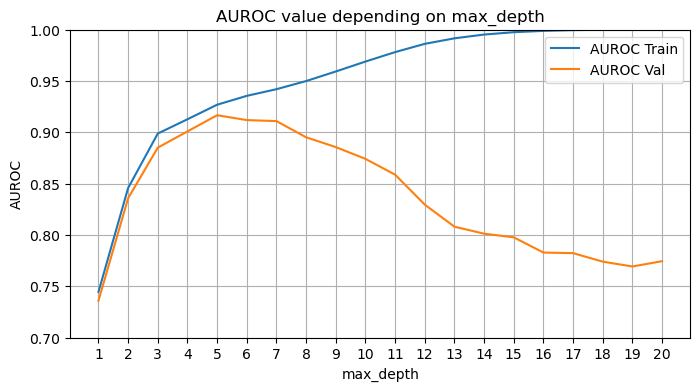

In [204]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, 21), auroc_train)
plt.plot(range(1, 21), auroc_val)
plt.legend(['AUROC Train', 'AUROC Val'])
plt.xlabel('max_depth')
plt.ylabel('AUROC')
plt.title("AUROC value depending on max_depth")
plt.xticks(range(1, 21))
plt.ylim([0.7, 1.0])
plt.grid()
plt.show()

**Висновок.** Найкраще значення `max_depth` = 5, тому що після нього оцінка для Валідаційного набору знижається, а отже йде оверфіт.

**Завдання 5**.
1. Натренуйте модель `DecisionTree` з найкращим значенням `max_depth`, яке ви знайшли на попередній ітерації.
2. Завантажте тестові дані змагання з `test.csv`.
3. Зробіть попередню обробку даних з функцією `preprocess_new_data` з вашого модуля `process_bank_churn.py`.
4. Зробіть передбачення використовуючи цю модель на тестових даних змагання.
5. Сформуйте `submission.csv`.
6. Зробіть новий Submission на Kaggle і додайте тут скріншот Вашого скору на паблік лідерборді :)


In [205]:
# The best model from previous task
model = DecisionTreeClassifier(random_state=123, max_depth=5)
model.fit(data.X_train, data.y_train)

predict_and_get_auroc(model, 'Train', data.X_train, data.y_train)
predict_and_get_auroc(model, 'Validation', data.X_val, data.y_val)

Train AUROC: 0.9268181038425859
Validation AUROC: 0.9165944166266548


0.9165944166266548

In [206]:
# Read Test dataset from a file
test_raw_df = pd.read_csv('test.csv')
test_raw_df.columns

Index(['id', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary'],
      dtype='object')

In [207]:
# Preprocess test data
X_test = pbc.preprocess_new_data(test_raw_df, data)

# Calculate probabilities for test and put them into the dataframe
test_raw_df['Exited'] = model.predict_proba(X_test)[:, 1]

# Read submission file
submission = pd.read_csv('sample_submission.csv')

# Copy results to submission data frame
submission['Exited'] = submission['id'].map(test_raw_df.set_index('id')['Exited'])
print(submission.head())

# Check for missed values
print(submission.info())

# Write submission into a file
submission.to_csv('submission_tree_depth_5.csv', index=False)

      id    Exited
0  15000  0.194357
1  15001  0.031787
2  15002  0.031787
3  15003  0.767123
4  15004  0.031787
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      10000 non-null  int64  
 1   Exited  10000 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 156.4 KB
None


Me in leaderboard currently:
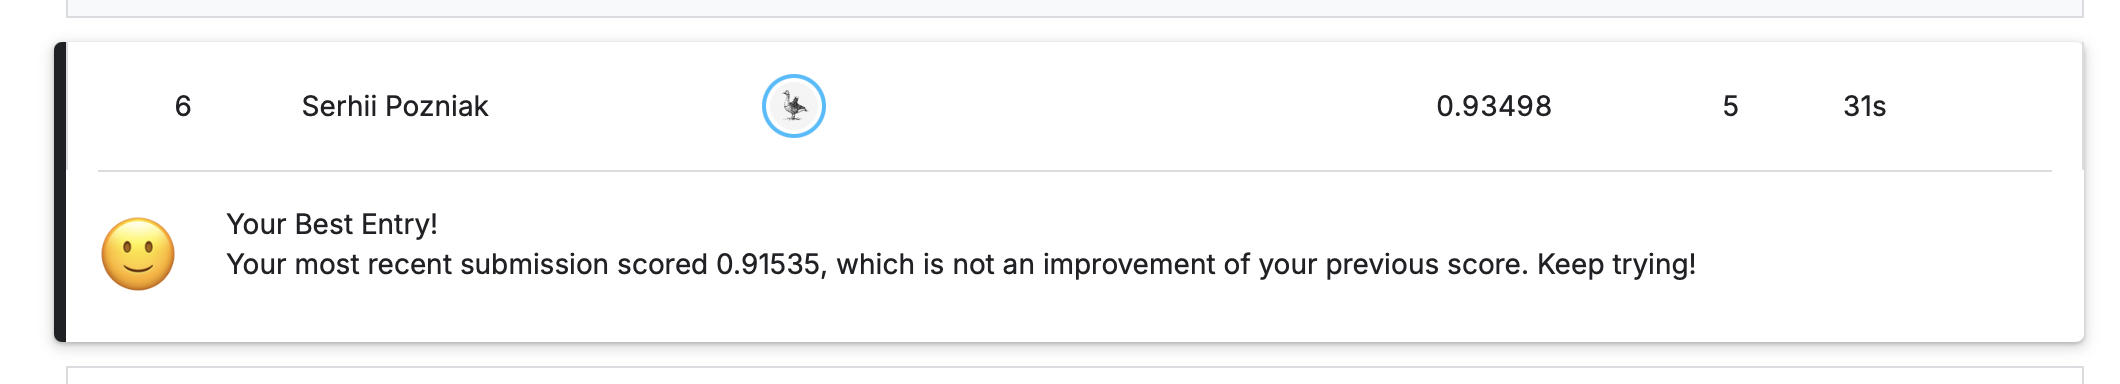